# Emotion Intensity Residual Stream — Activation Analysis

Shape: `(N, 8 emotions, 3 intensities, 6 layers, 4096 hidden)`

1. Load data & inspect shape / metadata  
2. PCA per layer — emotion coloring  
3. PCA per layer — intensity coloring  
4. Logistic Regression: 8-class emotion per layer  
5. Logistic Regression: 3-class intensity per layer  
6. Cosine similarity heatmap of emotion vectors per layer  
7. `high − low` intensity direction consistency across emotions


## 1. Import Libraries and Configuration

In [14]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

# ── Paths ────────────────────────────────────────────────────────────────────
REPO_ROOT   = Path("../..").resolve()
ACT_DIR     = REPO_ROOT / "activation" / "emotion_rewrites"
NPY_PATH    = ACT_DIR / "emotion_intensity_residual_stream.npy"
INFO_PATH   = ACT_DIR / "emotion_intensity_residual_stream_info.json"

# ── Metadata ─────────────────────────────────────────────────────────────────
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYER_INDICES  = INFO["layer_indices"]          # [8, 10, 13, 16, 19, 22]
EMOTION_ORDER  = INFO["emotion_order"]          # 8 Plutchik emotions
INTENSITY_ORDER = INFO["intensity_order"]       # ["low", "medium", "high"]
SOURCE_IDS     = INFO["source_ids"]
SHAPE          = tuple(INFO["shape"])           # (N, 8, 3, 6, 4096)
DTYPE          = INFO.get("dtype", "float32")

N, N_EMO, N_INT, N_LAYERS, D = SHAPE

print(f"Activation tensor shape : {SHAPE}")
print(f"Layer indices            : {LAYER_INDICES}")
print(f"Emotions ({N_EMO})         : {EMOTION_ORDER}")
print(f"Intensities ({N_INT})      : {INTENSITY_ORDER}")
print(f"# source texts           : {N}")
print(f"Hidden dim               : {D}")


Activation tensor shape : (22782, 8, 3, 6, 4096)
Layer indices            : [8, 10, 13, 16, 19, 22]
Emotions (8)         : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Intensities (3)      : ['low', 'medium', 'high']
# source texts           : 22782
Hidden dim               : 4096


## 2. Load Activation Data and Inspect Shape / Metadata

In [15]:
# Load as memory-mapped array (no full copy into RAM).
# Shape: (N, N_EMO, N_INT, N_LAYERS, D)
act = np.memmap(str(NPY_PATH), dtype=DTYPE, mode="r", shape=SHAPE)

print(f"Loaded act  shape : {act.shape}  dtype : {act.dtype}")
print()

# Per-layer statistics (compute on a random subset to avoid OOM)
rng = np.random.default_rng(42)
subset_idx = rng.choice(N, size=min(2000, N), replace=False)

print(f"{'Layer':>6}  {'mean':>10}  {'std':>10}  {'min':>10}  {'max':>10}")
print("-" * 52)
for li, layer in enumerate(LAYER_INDICES):
    vals = act[subset_idx, :, :, li, :].reshape(-1).astype(np.float64)
    print(f"  {layer:>4}  {vals.mean():>10.4f}  {vals.std():>10.4f}"
          f"  {vals.min():>10.4f}  {vals.max():>10.4f}")


Loaded act  shape : (22782, 8, 3, 6, 4096)  dtype : float32

 Layer        mean         std         min         max
----------------------------------------------------
     8     -0.0011      0.0829     -1.4453      3.1562
    10     -0.0002      0.1033     -1.5781      4.0625
    13     -0.0021      0.1238     -1.5156      4.4688
    16     -0.0030      0.1708     -2.3281      5.7500
    19     -0.0053      0.2417     -5.6250      7.0000
    22     -0.0043      0.3231    -10.5625      6.6875


In [16]:
# ── Prototype vectors: mean over N sources ────────────────────────────────────
# proto[e, i, li, :]  →  shape (N_EMO, N_INT, N_LAYERS, D)
# Compute in chunks to keep memory usage low.
CHUNK = 500
proto = np.zeros((N_EMO, N_INT, N_LAYERS, D), dtype=np.float64)
counts = 0
for start in range(0, N, CHUNK):
    end = min(start + CHUNK, N)
    proto += act[start:end].sum(axis=0, dtype=np.float64)   # sum over N dim
    counts += end - start
proto /= counts   # divide by N → mean

print(f"Prototype tensor shape : {proto.shape}  (emotion × intensity × layer × D)")
print(f"Global prototype mean  : {proto.mean():.6f}")


Prototype tensor shape : (8, 3, 6, 4096)  (emotion × intensity × layer × D)
Global prototype mean  : -0.002651


In [17]:
# ── Subsample raw activations (used for PCA & LogReg) ────────────────────────
# Take up to MAX_PER_CELL source texts per (emotion, intensity) cell.
MAX_PER_CELL = 300   # → 8 × 3 × 300 = 7200 rows total

rng_sub  = np.random.default_rng(0)
chosen_n = rng_sub.choice(N, size=min(N, MAX_PER_CELL), replace=False)

n_samples = len(chosen_n) * N_EMO * N_INT
y_emo_all = np.empty(n_samples, dtype=np.int8)
y_int_all = np.empty(n_samples, dtype=np.int8)
X_layers  = np.empty((N_LAYERS, n_samples, D), dtype=np.float32)

idx = 0
for ei in range(N_EMO):
    for ii in range(N_INT):
        sl = slice(idx, idx + len(chosen_n))
        # act[chosen_n, ei, ii, :, :] → (n, N_LAYERS, D) → transpose to (N_LAYERS, n, D)
        X_layers[:, sl, :] = act[chosen_n, ei, ii, :, :].transpose(1, 0, 2)
        y_emo_all[sl] = ei
        y_int_all[sl] = ii
        idx += len(chosen_n)

print(f"X_layers shape : {X_layers.shape}  (layers × samples × D)")
print(f"n_samples      : {n_samples}  "
      f"({len(chosen_n)} sources × {N_EMO} emotions × {N_INT} intensities)")
print(f"Emotion dist   : {np.bincount(y_emo_all)}")
print(f"Intensity dist : {np.bincount(y_int_all)}")


X_layers shape : (6, 7200, 4096)  (layers × samples × D)
n_samples      : 7200  (300 sources × 8 emotions × 3 intensities)
Emotion dist   : [900 900 900 900 900 900 900 900]
Intensity dist : [2400 2400 2400]


## 3. PCA per Layer — Emotion Coloring

Each point = one raw activation from the subsampled set (~7200 points per layer).  
Colors encode the 8 emotion categories.


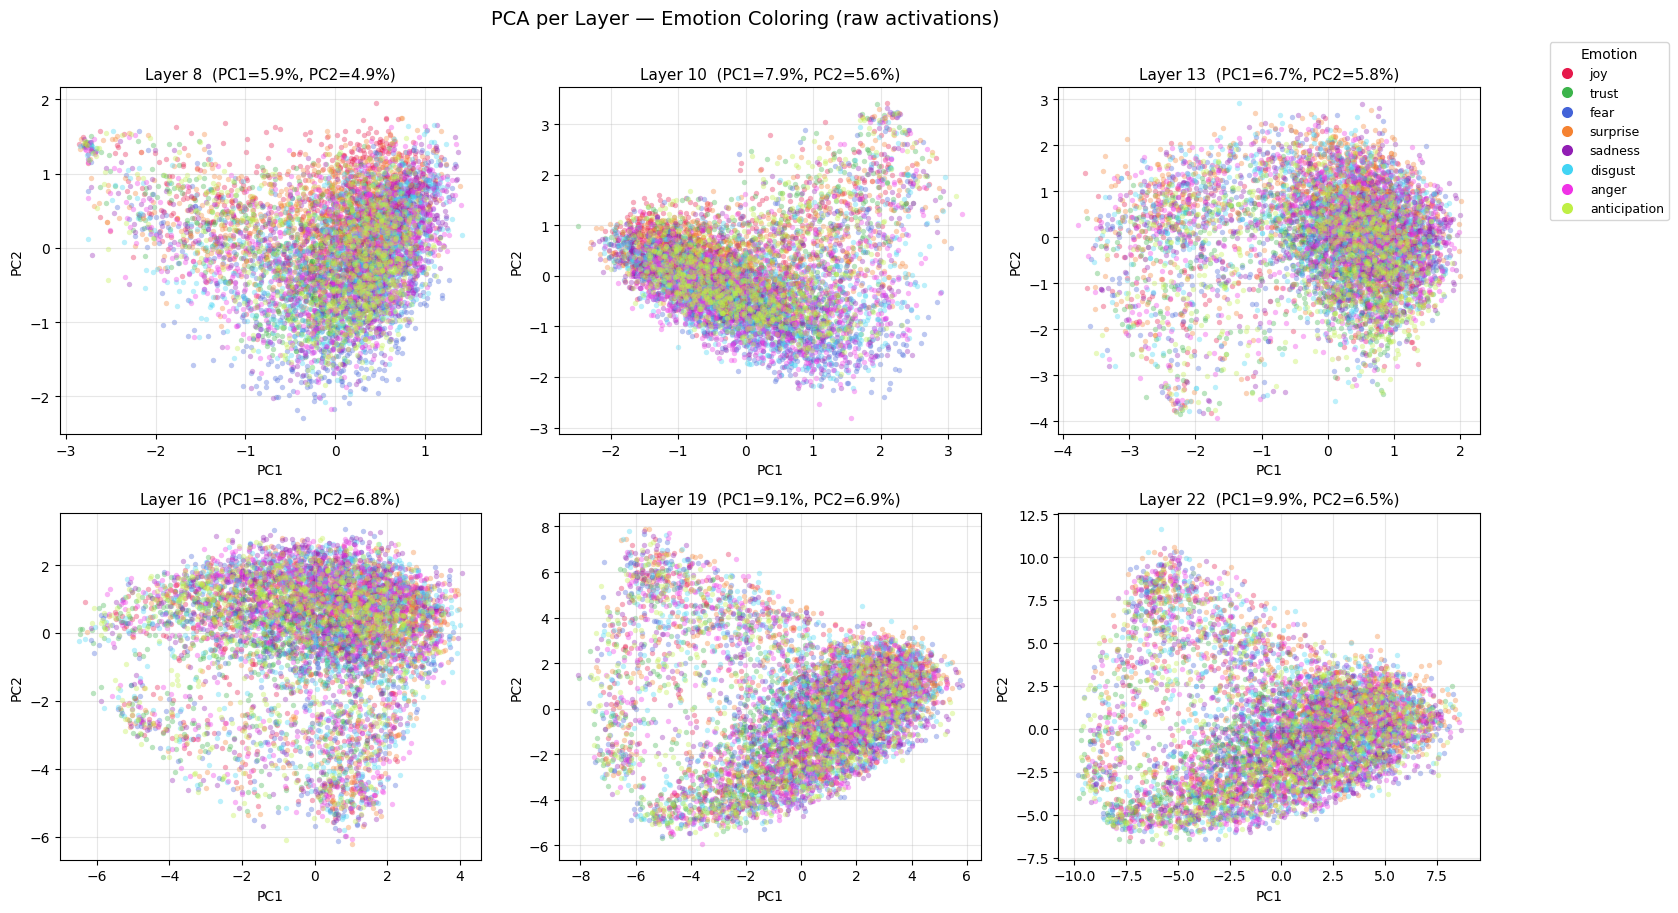

In [18]:
EMO_COLORS = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45",
]
INT_COLORS  = {"low": "#4575b4", "medium": "#fdae61", "high": "#d73027"}
INT_MARKERS = {"low": "o", "medium": "s", "high": "^"}

# Fit PCA on raw subsampled activations per layer
layer_pcas   = []
layer_coords = []

for li in range(N_LAYERS):
    X = X_layers[li]   # (n_samples, D)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    layer_pcas.append(pca)
    layer_coords.append(coords)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for li, ax in enumerate(axes):
    coords = layer_coords[li]
    pca    = layer_pcas[li]
    evr    = pca.explained_variance_ratio_

    for ei, emo in enumerate(EMOTION_ORDER):
        mask = y_emo_all == ei
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            color=EMO_COLORS[ei], label=emo,
            s=15, alpha=0.35, linewidths=0, rasterized=True,
        )

    ax.set_title(
        f"Layer {LAYER_INDICES[li]}  "
        f"(PC1={evr[0]:.1%}, PC2={evr[1]:.1%})",
        fontsize=11,
    )
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=EMO_COLORS[ei], markersize=9, label=emo)
    for ei, emo in enumerate(EMOTION_ORDER)
]
fig.legend(handles=handles, title="Emotion", loc="upper right",
           bbox_to_anchor=(1.12, 0.98), fontsize=9)
fig.suptitle("PCA per Layer — Emotion Coloring (raw activations)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 4. PCA per Layer — Intensity Coloring

Same PCA coordinates; colors encode the 3 intensity levels.  
Marker shape distinguishes intensity within each emotion group.


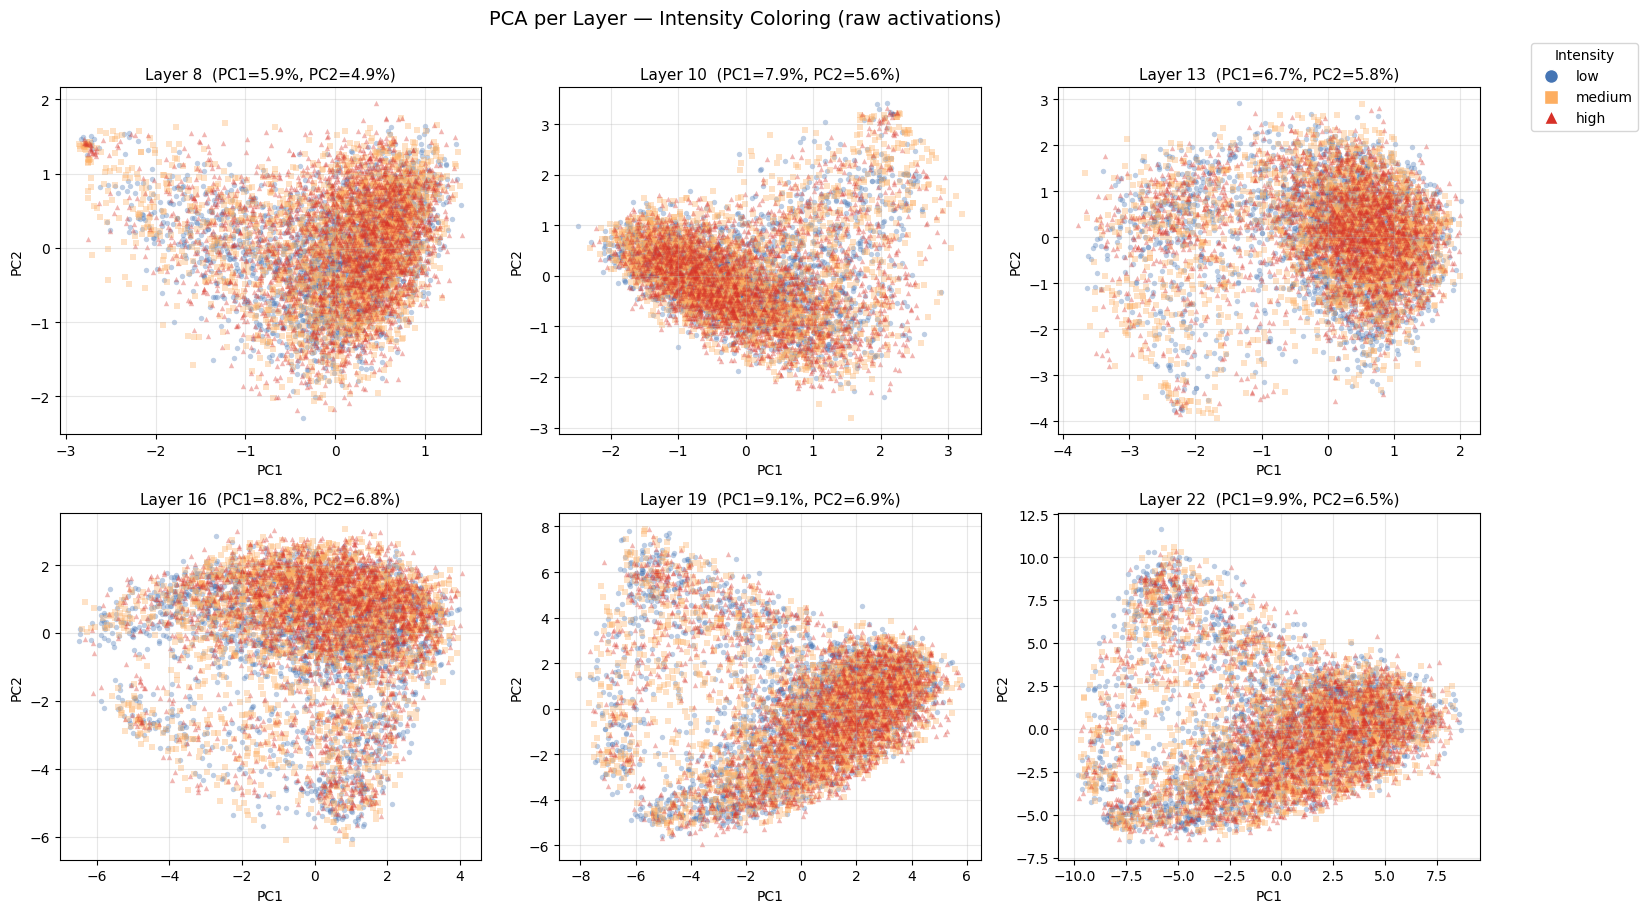

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for li, ax in enumerate(axes):
    coords = layer_coords[li]
    pca    = layer_pcas[li]
    evr    = pca.explained_variance_ratio_

    for ii, intens in enumerate(INTENSITY_ORDER):
        mask = y_int_all == ii
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            color=INT_COLORS[intens],
            marker=INT_MARKERS[intens],
            label=intens,
            s=15, alpha=0.35, linewidths=0, rasterized=True,
        )

    ax.set_title(
        f"Layer {LAYER_INDICES[li]}  "
        f"(PC1={evr[0]:.1%}, PC2={evr[1]:.1%})",
        fontsize=11,
    )
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

handles = [
    plt.Line2D([0], [0], marker=INT_MARKERS[intens], color="w",
               markerfacecolor=INT_COLORS[intens], markersize=10, label=intens)
    for intens in INTENSITY_ORDER
]
fig.legend(handles=handles, title="Intensity", loc="upper right",
           bbox_to_anchor=(1.10, 0.98), fontsize=10)
fig.suptitle("PCA per Layer — Intensity Coloring (raw activations)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 5. Logistic Regression: 8-class Emotion Classification per Layer

Sampled from raw activations (`act`) using a stratified 80/20 split.  
Subsampling cap per `(emotion, intensity)` cell keeps memory usage bounded.


In [20]:
# X_layers, y_emo_all, y_int_all were built in the data preparation cell above.
print(f"Sample matrix shape per layer : {X_layers.shape[1:]}  (rows, D)")
print(f"Emotion label distribution    : {np.bincount(y_emo_all)}")
print(f"Intensity label distribution  : {np.bincount(y_int_all)}")


Sample matrix shape per layer : (7200, 4096)  (rows, D)
Emotion label distribution    : [900 900 900 900 900 900 900 900]
Intensity label distribution  : [2400 2400 2400]


In [22]:
def run_logreg(X: np.ndarray, y: np.ndarray) -> dict:
    """Stratified 80/20 split → LogisticRegression → return metrics dict."""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(sss.split(X, y))
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    clf = LogisticRegression(max_iter=1000, solver="lbfgs",
                             C=1.0, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return {
        "acc":  accuracy_score(y_te, y_pred),
        "f1":   f1_score(y_te, y_pred, average="macro"),
        "clf":  clf,
        "y_te": y_te,
        "y_pred": y_pred,
    }


# ── Emotion classification ────────────────────────────────────────────────────
emo_results = {}
for li in range(N_LAYERS):
    emo_results[li] = run_logreg(X_layers[li], y_emo_all)
    print(f"Layer {LAYER_INDICES[li]:>2}  acc={emo_results[li]['acc']:.3f}  "
          f"macro-F1={emo_results[li]['f1']:.3f}")


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer  8  acc=0.826  macro-F1=0.826


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 10  acc=0.822  macro-F1=0.822


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

Layer 16  acc=0.806  macro-F1=0.806


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 19  acc=0.767  macro-F1=0.767


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 22  acc=0.738  macro-F1=0.738


In [23]:
best_emo_li = max(emo_results, key=lambda li: emo_results[li]["acc"])
print(f"\n=== Best layer for emotion: {LAYER_INDICES[best_emo_li]} ===")
print(classification_report(
    emo_results[best_emo_li]["y_te"],
    emo_results[best_emo_li]["y_pred"],
    target_names=EMOTION_ORDER,
    digits=3,
))



=== Best layer for emotion: 13 ===
              precision    recall  f1-score   support

         joy      0.877     0.911     0.894       180
       trust      0.949     0.922     0.935       180
        fear      0.843     0.833     0.838       180
    surprise      0.910     0.894     0.902       180
     sadness      0.827     0.794     0.810       180
     disgust      0.665     0.706     0.685       180
       anger      0.701     0.689     0.695       180
anticipation      0.874     0.883     0.878       180

    accuracy                          0.829      1440
   macro avg      0.830     0.829     0.830      1440
weighted avg      0.830     0.829     0.830      1440



## 6. Logistic Regression: 3-class Intensity Classification per Layer

In [24]:
int_results = {}
for li in range(N_LAYERS):
    int_results[li] = run_logreg(X_layers[li], y_int_all)
    print(f"Layer {LAYER_INDICES[li]:>2}  acc={int_results[li]['acc']:.3f}  "
          f"macro-F1={int_results[li]['f1']:.3f}")

best_int_li = max(int_results, key=lambda li: int_results[li]["acc"])
print(f"\n=== Best layer for intensity: {LAYER_INDICES[best_int_li]} ===")
print(classification_report(
    int_results[best_int_li]["y_te"],
    int_results[best_int_li]["y_pred"],
    target_names=INTENSITY_ORDER,
    digits=3,
))


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer  8  acc=0.694  macro-F1=0.695


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 10  acc=0.713  macro-F1=0.713


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

Layer 16  acc=0.713  macro-F1=0.713


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 19  acc=0.689  macro-F1=0.688


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 22  acc=0.659  macro-F1=0.659

=== Best layer for intensity: 13 ===
              precision    recall  f1-score   support

         low      0.840     0.821     0.830       480
      medium      0.630     0.600     0.615       480
        high      0.733     0.785     0.759       480

    accuracy                          0.735      1440
   macro avg      0.735     0.735     0.735      1440
weighted avg      0.735     0.735     0.735      1440



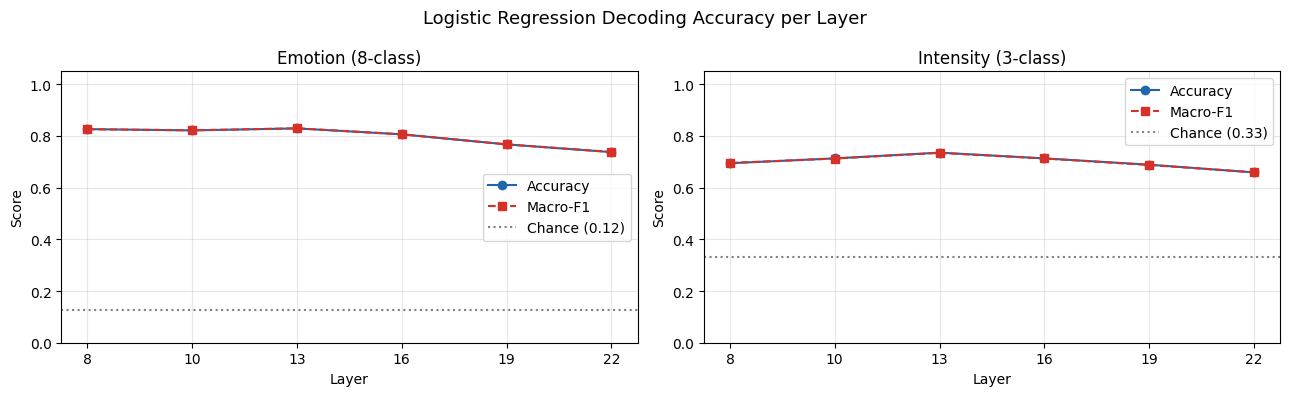

In [25]:
# ── Comparison plot: emotion vs intensity accuracy across layers ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

layer_ticks = [str(l) for l in LAYER_INDICES]

for ax, results, title, chance in [
    (axes[0], emo_results, "Emotion (8-class)", 1/8),
    (axes[1], int_results, "Intensity (3-class)", 1/3),
]:
    accs = [results[li]["acc"] for li in range(N_LAYERS)]
    f1s  = [results[li]["f1"]  for li in range(N_LAYERS)]
    ax.plot(layer_ticks, accs, "o-", label="Accuracy", color="#2166ac")
    ax.plot(layer_ticks, f1s,  "s--", label="Macro-F1", color="#d73027")
    ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Logistic Regression Decoding Accuracy per Layer", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Cosine Similarity Heatmap of Emotion Vectors per Layer

Emotion vector = mean over all intensities → shape `(D,)` per emotion per layer.


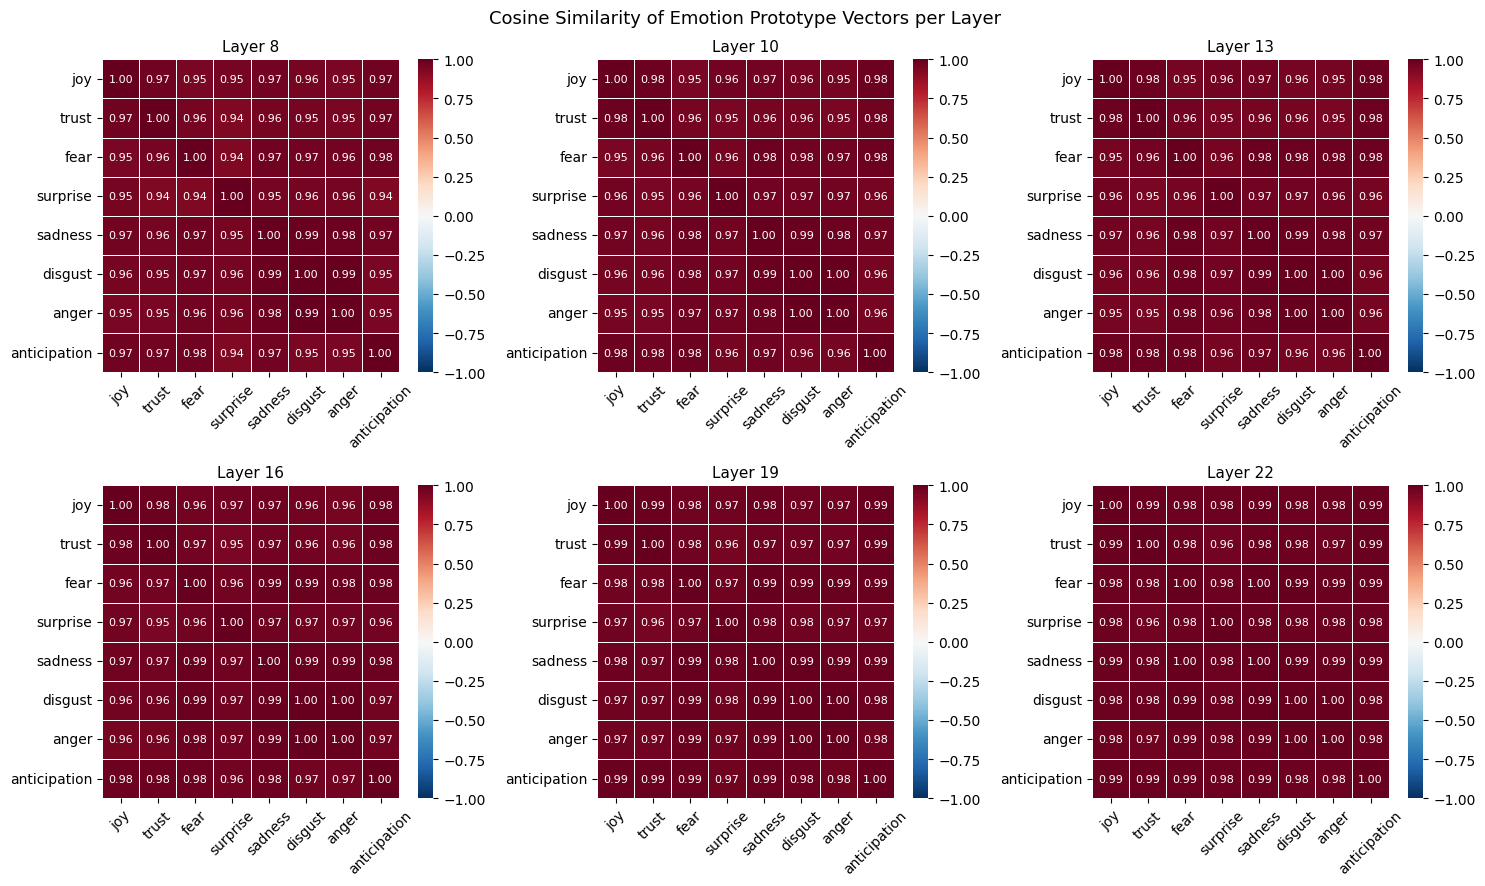

In [26]:
def cosine_sim_matrix(vecs: np.ndarray) -> np.ndarray:
    """vecs: (K, D) → (K, K) cosine similarity matrix."""
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-10, norms)
    normed = vecs / norms
    return normed @ normed.T


# Emotion prototype: mean over intensity dimension → (N_EMO, N_LAYERS, D)
emo_vecs = proto.mean(axis=1)   # axis=1 is intensity

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for li, ax in enumerate(axes):
    V  = emo_vecs[:, li, :].astype(np.float64)   # (N_EMO, D)
    CS = cosine_sim_matrix(V)

    sns.heatmap(
        CS,
        ax=ax,
        xticklabels=EMOTION_ORDER,
        yticklabels=EMOTION_ORDER,
        vmin=-1, vmax=1,
        cmap="RdBu_r",
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.4,
    )
    ax.set_title(f"Layer {LAYER_INDICES[li]}", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Cosine Similarity of Emotion Prototype Vectors per Layer", fontsize=13)
plt.tight_layout()
plt.show()


## 8. `high − low` Intensity Direction — Consistency Across Emotions

For each `(emotion, layer)` we compute the **intensity direction vector**:

$$\mathbf{d}_{e,l} = \bar{\mathbf{h}}_{e,\text{high},l} - \bar{\mathbf{h}}_{e,\text{low},l}$$

If a single shared intensity axis exists, the 8 direction vectors should be
near-parallel (high pairwise cosine similarity).


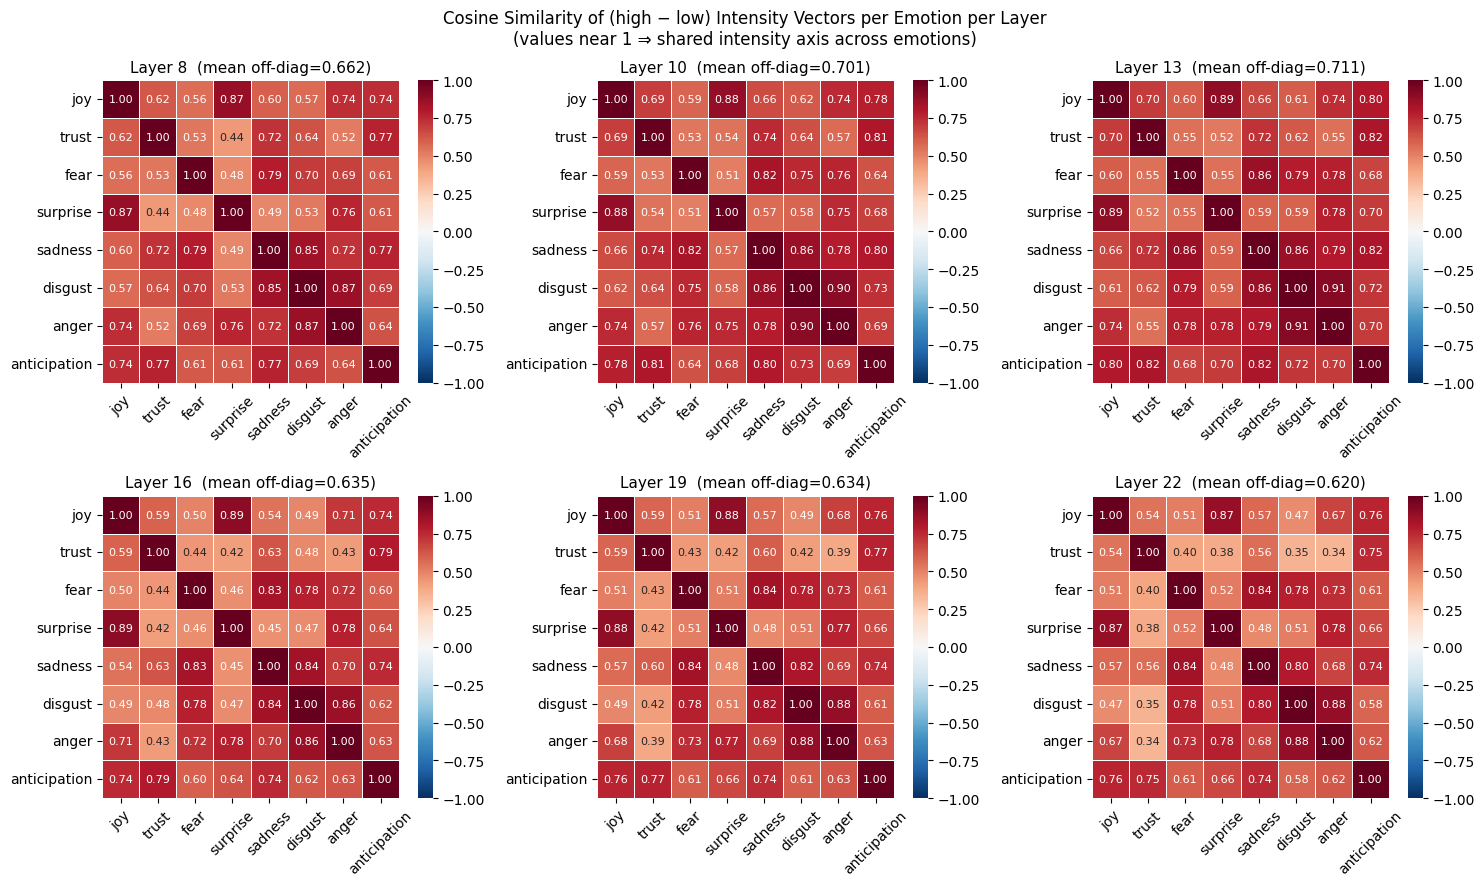

In [27]:
HIGH_IDX = INTENSITY_ORDER.index("high")
LOW_IDX  = INTENSITY_ORDER.index("low")

# intensity_dirs[e, li, :]  →  shape (N_EMO, N_LAYERS, D)
intensity_dirs = proto[:, HIGH_IDX, :, :] - proto[:, LOW_IDX, :, :]
# proto shape: (N_EMO, N_INT, N_LAYERS, D)  →  [:, h, :, :] is (N_EMO, N_LAYERS, D)

# ── Pairwise cosine similarity heatmaps ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
mean_off_diag = []

for li, ax in enumerate(axes):
    D_vecs = intensity_dirs[:, li, :].astype(np.float64)  # (N_EMO, D)
    CS = cosine_sim_matrix(D_vecs)

    # Mean off-diagonal similarity (upper triangle)
    mask_upper = np.triu(np.ones_like(CS, dtype=bool), k=1)
    mu = CS[mask_upper].mean()
    mean_off_diag.append(mu)

    sns.heatmap(
        CS,
        ax=ax,
        xticklabels=EMOTION_ORDER,
        yticklabels=EMOTION_ORDER,
        vmin=-1, vmax=1,
        cmap="RdBu_r",
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.4,
    )
    ax.set_title(f"Layer {LAYER_INDICES[li]}  (mean off-diag={mu:.3f})", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Cosine Similarity of (high − low) Intensity Vectors per Emotion per Layer\n"
    "(values near 1 ⇒ shared intensity axis across emotions)",
    fontsize=12,
)
plt.tight_layout()
plt.show()


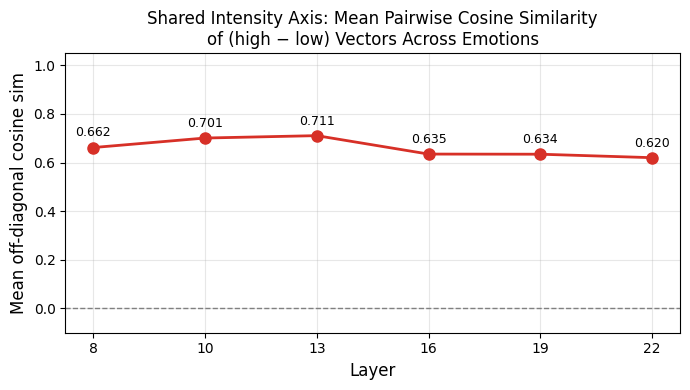


Mean off-diagonal cosine similarity per layer:
  Layer  8: 0.6617
  Layer 10: 0.7008
  Layer 13: 0.7106
  Layer 16: 0.6348
  Layer 19: 0.6343
  Layer 22: 0.6200


In [28]:
# ── Summary: mean off-diagonal cosine similarity across layers ────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([str(l) for l in LAYER_INDICES], mean_off_diag, "o-",
        color="#d73027", linewidth=2, markersize=8)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Mean off-diagonal cosine sim", fontsize=12)
ax.set_title(
    "Shared Intensity Axis: Mean Pairwise Cosine Similarity\n"
    "of (high − low) Vectors Across Emotions",
    fontsize=12,
)
ax.set_ylim(-0.1, 1.05)
ax.grid(True, alpha=0.3)

for x, y in zip([str(l) for l in LAYER_INDICES], mean_off_diag):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nMean off-diagonal cosine similarity per layer:")
for li, mu in enumerate(mean_off_diag):
    print(f"  Layer {LAYER_INDICES[li]:>2}: {mu:.4f}")
